# Lab 3 — Imbalanced Data, SMOTE & ROC/PR Analysis

**DSA 8401 Applied Machine Learning · Chapter 3**

## What are we learning?

In this lab we are building and evaluating a fraud-classification model using the mobile-money dataset.

The positive class is `is_fraud = 1`. Fraud is relatively rare, so this is an **imbalanced classification problem**.

The lab focuses on an important practical question:

> **How do we evaluate a model when the event we care about is rare and the cost of missing it is much higher than the cost of investigating a false alarm?**

We will:

1. Rebuild all Lab 2 features.
2. Understand the class imbalance and the accuracy trap.
3. Build Logistic Regression, Linear SVM and Naive Bayes models.
4. Put preprocessing inside a `Pipeline`.
5. Compare models using stratified 5-fold cross-validation.
6. Study ROC-AUC and PR-AUC.
7. Examine calibration and the Brier score.
8. Compare threshold moving, `class_weight` and SMOTE-NC.
9. Choose a decision threshold using business costs.
10. Produce a simple decision memo.

**Important:** We keep the complete feature set from the original notebook. The code is simplified for readability, but the analytical methodology is retained.

## Business framing

We treat fraud as the **positive class**.

There are two important mistakes:

- **False Negative (FN):** A fraudulent transaction is not flagged.
- **False Positive (FP):** A legitimate transaction is incorrectly flagged.

For this lab:

- Cost of a false negative = **KES 10,000**
- Cost of a false positive = **KES 800**

Because missing fraud is much more expensive than investigating a false alarm, the best probability threshold is expected to be much lower than the usual `0.50`.

The cost-based threshold is:

`t* = C_FP / (C_FP + C_FN)`

In [2]:
# ---------------------------------------------------------
# IMPORT LIBRARIES AND DEFINE BUSINESS SETTINGS
# ---------------------------------------------------------

import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# The model only uses information available before this date.
SCORING_TS = pd.Timestamp("2026-08-01 00:00:00")

# Business cost of each type of classification error.
C_FN = 10_000   # Cost of missing a fraudulent transaction
C_FP = 800      # Cost of incorrectly flagging a legitimate transaction

# Calculate the cost-optimal probability threshold.
T_STAR = C_FP / (C_FP + C_FN)

print(f"Cost-optimal threshold = {T_STAR:.4f}")

Cost-optimal threshold = 0.0741


## 0. Rebuild the Lab 2 features

### What are we doing?

We start with the same cleaning and feature engineering used in Lab 2.

The goal is to create **one modelling row per customer**.

For each customer we use:

- their most recent transaction as the application/decision row;
- customer-level behavioural features calculated from their transactions up to the scoring date.

This prevents the same customer from appearing in multiple modelling rows and makes the later stratified cross-validation easier to interpret.

In [3]:
# ---------------------------------------------------------
# LOAD THE MOBILE-MONEY DATA
# ---------------------------------------------------------

# Read the transaction data.
df = pd.read_csv("mobile_money_statements.csv")

# Remove duplicate transactions.
df = df.drop_duplicates().reset_index(drop=True)

print("Number of transactions:", len(df))

Number of transactions: 180000


### Step 0.1 — Clean transaction amounts

The `amount` field can contain values such as:

- `1,500/-`
- `(227/-)`
- `4,742/- Dr`

We convert these text values into a numeric signed amount.

We keep two versions:

- `amount_signed` — preserves the direction of the transaction.
- `amount_abs` — contains the absolute transaction value.

In [4]:
df['amount'].unique()

array(['1,329/- Dr', '289/- Dr', '1,571/-', ..., '36/-', '(7,970/-)',
       '(5,718/-)'], dtype=object)

In [5]:
# function in python


def function_name(arg1, arg2):
    # function body
    # Use the arguments to perform some operations
    result = arg1 + arg2  # Example operation
    return result
    
    
# call the function

function_name(5, 10)  # This will return 15

15

In [6]:
# CLEAN TRANSACTION AMOUNTS


def parse_amount(value):
    
    # Convert the value to text and remove extra spaces.
    value = str(value).strip()

    # Identify transactions that should be negative.
    
    is_negative = (
        value.startswith("(")
        or value.startswith("-")
        or "Dr" in value
    )

    # Keep only numeric characters.
    numbers = re.sub(r"[^0-9]", "", value)

    # If there is no numeric value, return a missing value.
    if numbers == "":
        return np.nan

    amount = float(numbers)

    # Apply the negative sign where required.
    if is_negative:
        amount = -amount

    return amount


# Apply the cleaning function.
df["amount_signed"] = df["amount"].apply(parse_amount)

# Absolute value represents the size of the transaction.
df["amount_abs"] = df["amount_signed"].abs()

df[["amount", "amount_signed", "amount_abs"]].head()

,amount,amount_signed,amount_abs
0,"1,329/- Dr",-1329.0,1329.0
1,289/- Dr,-289.0,289.0
2,"1,571/-",1571.0,1571.0
3,599/- Dr,-599.0,599.0
4,"(1,307/-)",-1307.0,1307.0


### Step 0.2  Convert transaction dates

The original data contains transactions stored in different date formats.

We therefore try the three formats one after another.

After this step, every valid transaction date is stored in the same `ts` column as a pandas datetime.

In [7]:
# CONVERT THE DIFFERENT DATE FORMATS

date_text = df["txn_time"].astype(str)

# Try date format 1.
ts = pd.to_datetime(
                date_text,
                format="%Y-%m-%d %H:%M:%S",
                errors="coerce"
            )

# For values that failed, try date format 2.
missing = ts.isna()

ts.loc[missing] = pd.to_datetime(
    date_text[missing],
    format="%d/%m/%Y %H:%M",
    errors="coerce"
)

# For values still missing, try date format 3.
missing = ts.isna()

ts.loc[missing] = pd.to_datetime(
    date_text[missing],
    format="%b %d, %Y %I:%M %p",
    errors="coerce"
)

# Save the final datetime column.
df["ts"] = ts

print("Missing dates:", df["ts"].isna().sum())

Missing dates: 0


### Step 0.3 — Identify customers and apply the scoring date

We standardise `reg_id` to create `customer_id`.

The scoring date acts as our **as-of date**. We only use transactions before the scoring date so that information from the future does not enter the model.

In [8]:
df

,txn_id,msisdn,reg_id,account_name,region,segment,txn_time,txn_type,amount,gps_lat,...,agent_id,device_id,counterparty,balance_after,manual_review_score,settlement_status,is_fraud,amount_signed,amount_abs,ts
0,TXN0102856,254700004022,NID101089,Joseph Mwangi,Kampala,retail,2026-06-30 14:24:19,send,"1,329/- Dr",NaN,...,AG1014,DV978723,CP6324,8123.0,0.061,settled,0,-1329.0,1329.0,2026-06-30 14:24:19
1,TXN0155490,254700013612,NID103658,Rehema Ndlovu,Mombasa,retail,"Jan 29, 2026 01:17 PM",send,289/- Dr,1.77470,...,AG1084,DV616667,CP2831,6322.0,0.000,settled,0,-289.0,289.0,2026-01-29 13:17:00
2,TXN0019434,254700005862,nid101584,Mary Mutua,Arusha,retail,"Sep 16, 2025 12:55 AM",receive,"1,571/-",-3.74336,...,AG1091,DV637734,CP167,15237.0,0.912,reversed,1,1571.0,1571.0,2025-09-16 00:55:00
3,TXN0049426,254700009223,NID102493,Joseph Okoth,Dar es Salaam,retail,07/04/2026 11:21,send,599/- Dr,NaN,...,AG1047,DV666470,CP3382,3322.0,0.095,settled,0,-599.0,599.0,2026-04-07 11:21:00
4,TXN0013816,254700014760,nid103963,B. Ssentongo,Mwanza,retail,20/12/2025 11:05,cashout,"(1,307/-)",0.08284,...,NaN,NaN,CP8428,2168.0,0.085,settled,0,-1307.0,1307.0,2025-12-20 11:05:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179995,TXN0066455,254700010750,NID102893,"Mutua, Grace",Dar es Salaam,retail,27/11/2025 18:15,airtime,(52/-),NaN,...,AG1191,DV964052,CP208,3910.0,0.047,settled,0,-52.0,52.0,2025-11-27 18:15:00
179996,TXN0053459,254700007228,nid101960,OSEI GRACE,Arusha,retail,"Jul 18, 2026 07:03 AM",send,"(1,003/-)",NaN,...,NaN,DV963852,CP6035,1685.0,0.033,settled,0,-1003.0,1003.0,2026-07-18 07:03:00
179997,TXN0010742,254700001728,NID100470,OTIENO FATUMA,Nakuru,retail,05/02/2026 05:33,receive,920/-,5.01451,...,AG1081,DV731612,CP8535,6909.0,0.941,settled,1,920.0,920.0,2026-02-05 05:33:00
179998,TXN0049689,254700000772,NID100206,Z. Ssentongo,Mombasa,retail,24/03/2026 01:18,bill,"(2,848/-)",-1.32258,...,AG1163,DV746921,CP8162,14790.0,0.912,reversed,1,-2848.0,2848.0,2026-03-24 01:18:00


In [9]:
# df[(df['region']=='Kampala') & (df['segment']=='retail')]


df.query('region == "Kampala" and segment == "retail"')

,txn_id,msisdn,reg_id,account_name,region,segment,txn_time,txn_type,amount,gps_lat,...,agent_id,device_id,counterparty,balance_after,manual_review_score,settlement_status,is_fraud,amount_signed,amount_abs,ts
0,TXN0102856,254700004022,NID101089,Joseph Mwangi,Kampala,retail,2026-06-30 14:24:19,send,"1,329/- Dr",NaN,...,AG1014,DV978723,CP6324,8123.0,0.061,settled,0,-1329.0,1329.0,2026-06-30 14:24:19
16,TXN0161399,254700003093,NID100836,Joseph Otieno,Kampala,retail,2025-03-23 03:45:14,cashout,"1,016/- Dr",0.15584,...,AG1266,DV819885,CP2714,13951.0,0.891,reversed,1,-1016.0,1016.0,2025-03-23 03:45:14
19,TXN0151599,254700006004,NID101623,Brian Okoth,Kampala,retail,2026-02-14 08:34:48,cashout,"(2,553/-)",-2.27081,...,AG1225,DV253925,CP4043,11484.0,0.035,settled,0,-2553.0,2553.0,2026-02-14 08:34:48
23,TXN0106385,254700000928,NID100252,WAMBUI KEVIN,Kampala,retail,13/05/2026 21:13,cashin,"6,135/-",-1.32806,...,AG1019,DV356352,CP4187,6539.0,0.103,settled,0,6135.0,6135.0,2026-05-13 21:13:00
26,TXN0068063,254700001680,NID100459,Samuel Kamau,Kampala,retail,2025-12-08 22:47:27,paybill,"(2,714/-)",NaN,...,AG1254,DV237878,CP8923,3584.0,0.099,settled,0,-2714.0,2714.0,2025-12-08 22:47:27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179897,TXN0131719,254700014360,NID103857,"Juma, Zawadi",Kampala,retail,09/05/2026 13:42,cashout,"-1,112/-",-0.29147,...,AG1265,DV111813,CP6058,3397.0,0.034,settled,0,-1112.0,1112.0,2026-05-09 13:42:00
179926,TXN0104972,254700010758,nid102895,OSEI GRACE,Kampala,retail,23/04/2025 16:50,receive,949/-,-0.16271,...,AG1379,DV248815,CP3020,58.0,0.914,reversed,1,949.0,949.0,2025-04-23 16:50:00
179938,TXN0106529,254700006726,NID101820,F. Ali,Kampala,retail,16/03/2026 23:52,cashin,"3,709/-",1.37110,...,AG1198,DV684503,CP3150,4610.0,0.065,settled,0,3709.0,3709.0,2026-03-16 23:52:00
179989,TXN0053593,254700010917,nid102935,Mary Okoth,Kampala,retail,"Apr 09, 2025 10:45 PM",cashin,"1,805/-",-3.73637,...,AG1070,DV183663,CP3747,5943.0,0.013,settled,0,1805.0,1805.0,2025-04-09 22:45:00


In [10]:
df

,txn_id,msisdn,reg_id,account_name,region,segment,txn_time,txn_type,amount,gps_lat,...,agent_id,device_id,counterparty,balance_after,manual_review_score,settlement_status,is_fraud,amount_signed,amount_abs,ts
0,TXN0102856,254700004022,NID101089,Joseph Mwangi,Kampala,retail,2026-06-30 14:24:19,send,"1,329/- Dr",NaN,...,AG1014,DV978723,CP6324,8123.0,0.061,settled,0,-1329.0,1329.0,2026-06-30 14:24:19
1,TXN0155490,254700013612,NID103658,Rehema Ndlovu,Mombasa,retail,"Jan 29, 2026 01:17 PM",send,289/- Dr,1.77470,...,AG1084,DV616667,CP2831,6322.0,0.000,settled,0,-289.0,289.0,2026-01-29 13:17:00
2,TXN0019434,254700005862,nid101584,Mary Mutua,Arusha,retail,"Sep 16, 2025 12:55 AM",receive,"1,571/-",-3.74336,...,AG1091,DV637734,CP167,15237.0,0.912,reversed,1,1571.0,1571.0,2025-09-16 00:55:00
3,TXN0049426,254700009223,NID102493,Joseph Okoth,Dar es Salaam,retail,07/04/2026 11:21,send,599/- Dr,NaN,...,AG1047,DV666470,CP3382,3322.0,0.095,settled,0,-599.0,599.0,2026-04-07 11:21:00
4,TXN0013816,254700014760,nid103963,B. Ssentongo,Mwanza,retail,20/12/2025 11:05,cashout,"(1,307/-)",0.08284,...,NaN,NaN,CP8428,2168.0,0.085,settled,0,-1307.0,1307.0,2025-12-20 11:05:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179995,TXN0066455,254700010750,NID102893,"Mutua, Grace",Dar es Salaam,retail,27/11/2025 18:15,airtime,(52/-),NaN,...,AG1191,DV964052,CP208,3910.0,0.047,settled,0,-52.0,52.0,2025-11-27 18:15:00
179996,TXN0053459,254700007228,nid101960,OSEI GRACE,Arusha,retail,"Jul 18, 2026 07:03 AM",send,"(1,003/-)",NaN,...,NaN,DV963852,CP6035,1685.0,0.033,settled,0,-1003.0,1003.0,2026-07-18 07:03:00
179997,TXN0010742,254700001728,NID100470,OTIENO FATUMA,Nakuru,retail,05/02/2026 05:33,receive,920/-,5.01451,...,AG1081,DV731612,CP8535,6909.0,0.941,settled,1,920.0,920.0,2026-02-05 05:33:00
179998,TXN0049689,254700000772,NID100206,Z. Ssentongo,Mombasa,retail,24/03/2026 01:18,bill,"(2,848/-)",-1.32258,...,AG1163,DV746921,CP8162,14790.0,0.912,reversed,1,-2848.0,2848.0,2026-03-24 01:18:00


In [11]:
# CREATE CUSTOMER ID AND APPLY THE AS-OF FILTER

df["customer_id"] = df["reg_id"].astype(str).str.strip().str.upper()


# Keep only transactions that happened before the scoring date.
df = df[df["ts"] < SCORING_TS].copy()

print("Transactions after as-of filtering:", len(df))

Transactions after as-of filtering: 180000


### Step 0.4 — Create transaction-level features

We now create features describing **when and how a transaction occurred**.

Important features include:

- transaction hour;
- day of week;
- cyclical representations of time;
- distance from the approximate payday dates;
- logarithm of transaction amount;
- an indicator showing whether GPS information is missing.

The sine/cosine features allow the model to understand that, for example, hour 23 and hour 0 are close together rather than being far apart numerically.

In [12]:
# CREATE TRANSACTION-LEVEL FEATURES

# Basic calendar features.
df["hour"] = df["ts"].dt.hour
df["dow"]  = df["ts"].dt.dayofweek
df["day"]  = df["ts"].dt.day

# Cyclical representation of the hour.

# This preserves the circular nature of time.
df["hr_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hr_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

# Cyclical representation of the day of the week.
df["dow_sin"] = np.sin(2 * np.pi * df["dow"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["dow"] / 7)

# Distance from the approximate payday dates.
df["payday_dist"] = np.minimum(
    abs(df["day"] - 1),
    abs(df["day"] - 28)
)

# Log transformation reduces the influence of extremely
# large transaction amounts.
df["log_amt"] = np.log1p(df["amount_abs"])

# Missing GPS can itself contain useful behavioural information.
df["gps_missing"] = df["gps_lat"].isna().astype(int)

### Step 0.5 — Create customer-level behavioural features

A single transaction does not tell us everything about a customer.

We therefore create customer-level features:

- **Recency:** How recently did the customer transact?
- **Frequency:** How many transactions has the customer made?
- **Monetary out:** Total amount sent/paid out.
- **Monetary in:** Total amount received.
- **Number of counterparties:** How many different counterparties does the customer interact with?
- **Cashout ratio:** What proportion of transactions are cash-outs?
- **Out/In ratio:** How large are outgoing transactions compared with incoming transactions?

These are behavioural features similar to RFM-style customer analysis.

In [13]:
# ---------------------------------------------------------
# CREATE CUSTOMER-LEVEL FEATURES
# ---------------------------------------------------------

# A debit represents money going out.
df["is_debit"] = df["amount_signed"] < 0

# Group all transactions by customer.
customer = df.groupby("customer_id")

# Create an empty table for customer-level features.
agg = pd.DataFrame()

# Recency:
# Number of days since the customer's most recent transaction.
agg["recency_days"] = (
    SCORING_TS - customer["ts"].max()
).dt.total_seconds() / 86400

# Frequency:
# Number of transactions made by the customer.
agg["frequency"] = customer.size()

# Monetary out:
# Total value of outgoing transactions.
agg["monetary_out"] = (
    df.assign(
        money_out=np.where(
            df["is_debit"],
            df["amount_abs"],
            0
        )
    )
    .groupby("customer_id")["money_out"]
    .sum()
)

# Monetary in:
# Total value of incoming transactions.
agg["monetary_in"] = (
    df.assign(
        money_in=np.where(
            ~df["is_debit"],
            df["amount_abs"],
            0
        )
    )
    .groupby("customer_id")["money_in"]
    .sum()
)

# Number of unique counterparties.
agg["n_counterparty"] = (
    customer["counterparty"].nunique()
)

# Proportion of transactions that are cash-outs.
agg["cashout_ratio"] = (
    df.assign(
        cashout=(df["txn_type"] == "cashout").astype(int)
    )
    .groupby("customer_id")["cashout"]
    .mean()
)

# Ratio of outgoing money to incoming money.
# We add 1 to the denominator to avoid division by zero.
agg["out_in_ratio"] = (
    agg["monetary_out"] /
    (agg["monetary_in"] + 1)
)

agg.head()

,recency_days,frequency,monetary_out,monetary_in,n_counterparty,cashout_ratio,out_in_ratio
customer_id,,,,,,,
NID100000,25.772222,7,8483.0,4467.0,7,0.142857,1.898612
NID100001,18.665278,39,42379.0,21204.0,39,0.230769,1.998538
NID100002,56.020833,7,13599.0,3768.0,7,0.142857,3.608119
NID100003,5.712500,22,16895.0,8955.0,22,0.227273,1.886445
NID100004,0.961111,108,104597.0,69488.0,107,0.138889,1.505231


### Step 0.6 — Create one modelling row per customer

We take each customer's most recent transaction and join the customer-level behavioural features to it.

This gives us one row per customer.

In [14]:
# CREATE THE FINAL CUSTOMER APPLICATION TABLE

app = (
    df.sort_values("ts")
      .groupby("customer_id")
      .tail(1)
      .merge(
          agg,
          on="customer_id"
      )
)

print("Application table shape:", app.shape)

Application table shape: (3991, 40)


In [15]:
app

,txn_id,msisdn,reg_id,account_name,region,segment,txn_time,txn_type,amount,gps_lat,...,log_amt,gps_missing,is_debit,recency_days,frequency,monetary_out,monetary_in,n_counterparty,cashout_ratio,out_in_ratio
0,TXN0010074,254700007005,nid101894,John Wambui,Mwanza,retail,2025-04-16 04:06:21,cashout,835/- Dr,-4.02354,...,6.728629,0,True,471.828924,1,835.0,0.0,1,1.000000,835.000000
1,TXN0179848,254700008829,NID102388,"Osei, Joseph",Nakuru,retail,2025-05-10 07:21:54,cashout,"-1,032/-",NaN,...,6.940222,1,True,447.693125,2,1819.0,0.0,2,0.500000,1819.000000
2,TXN0021867,254700014555,NID103909,Mary Wambui,Dar es Salaam,merchant,"May 13, 2025 02:04 AM",send,(408/-),NaN,...,6.013715,1,True,444.913889,2,1966.0,0.0,2,0.000000,1966.000000
3,TXN0106999,254700004251,NID101153,Mary Achieng,Mwanza,retail,"Jun 17, 2025 05:22 AM",receive,512/-,NaN,...,6.240276,1,False,409.776389,4,4211.0,1476.0,4,0.250000,2.851049
4,TXN0016471,254700010840,nid102913,Brian Juma,Eldoret,retail,2025-06-18 07:31:09,airtime,45/- Dr,NaN,...,3.828641,1,True,408.686701,2,148.0,0.0,2,0.000000,148.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3986,TXN0159259,254700004626,NID101259,J. Ssentongo,Kigali,agent,"Jul 31, 2026 08:09 PM",cashout,"-5,456/-",NaN,...,8.604654,1,True,0.160417,142,117371.0,119402.0,141,0.126761,0.982982
3987,TXN0092698,254700007093,NID101921,Zawadi Ssentongo,Mwanza,retail,2026-07-31 20:34:36,receive,"1,289/-",-1.33729,...,7.162397,0,False,0.142639,57,54351.0,52110.0,57,0.157895,1.042985
3988,TXN0038299,254700011953,NID103214,K. Otieno,Arusha,merchant,31/07/2026 21:20,cashin,"5,593/-",NaN,...,8.629450,1,False,0.111111,83,84274.0,71754.0,83,0.096386,1.174469
3989,TXN0115254,254700002991,NID100808,N. Mutua,Kigali,retail,"Jul 31, 2026 09:21 PM",cashin,"4,459/-",NaN,...,8.402904,1,False,0.110417,73,76114.0,59011.0,73,0.232877,1.289805


### Step 0.7 — Select all modelling features

We keep **all features from the original notebook**.

There are:

- 15 numerical features
- 3 categorical features

The target variable is `is_fraud`.

In [16]:
# ---------------------------------------------------------
# DEFINE ALL NUMERICAL AND CATEGORICAL FEATURES
# ---------------------------------------------------------

NUM = [
    "amount_abs",
    "log_amt",
    "hr_sin",
    "hr_cos",
    "dow_sin",
    "dow_cos",
    "payday_dist",
    "gps_missing",
    "recency_days",
    "frequency",
    "monetary_out",
    "monetary_in",
    "n_counterparty",
    "cashout_ratio",
    "out_in_ratio"
]

CAT = [
    "txn_type",
    "region",
    "segment"
]

# X contains all predictor variables.
X = app[NUM + CAT].copy()

# y contains the fraud target.
y = app["is_fraud"].values

print("Number of features:", len(NUM) + len(CAT))
print("Rows:", len(X))
print("Fraud prevalence:", round(y.mean(), 4))

Number of features: 18
Rows: 3991
Fraud prevalence: 0.0799


<Axes: xlabel='is_fraud'>

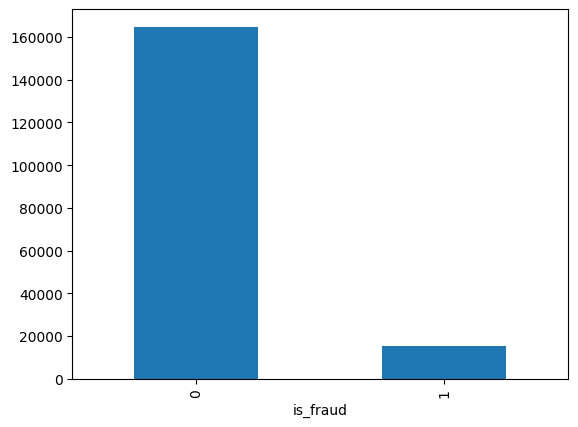

In [17]:

df['is_fraud'].value_counts().plot(kind='bar')

## 1. Understand class imbalance

### Why does imbalance matter?

If only a small percentage of customers are fraudulent, a model can obtain very high accuracy simply by predicting "not fraud" for almost everyone.

For example, if 92% of customers are legitimate, a model that always predicts "not fraud" can achieve about 92% accuracy while detecting **zero fraud cases**.

This is called the **accuracy trap**.

Therefore, we will pay particular attention to **PR-AUC**, along with ROC-AUC and other metrics.

In [18]:
# CHECK THE TARGET DISTRIBUTION

print("Number of non-fraud cases:", (y == 0).sum())
print("Number of fraud cases:", (y == 1).sum())

print("\nClass proportions:")
print(
    pd.Series(y)
    .value_counts(normalize=True)
    .sort_index()
)

Number of non-fraud cases: 3672
Number of fraud cases: 319

Class proportions:
0    0.92007
1    0.07993
Name: proportion, dtype: float64


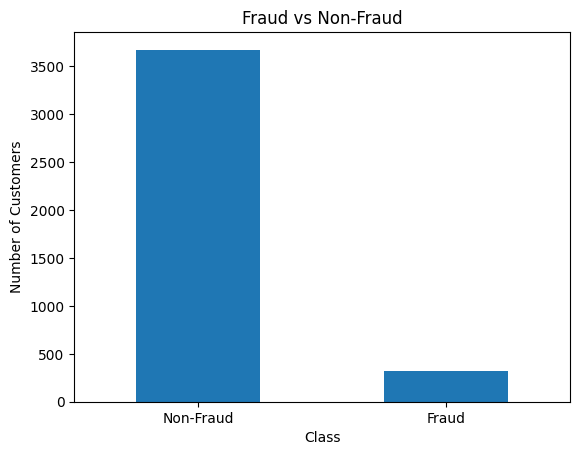

In [19]:
# VISUALISE CLASS IMBALANCE

pd.Series(y).value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Fraud vs Non-Fraud")
plt.xlabel("Class")
plt.ylabel("Number of Customers")
plt.xticks(
    [0, 1],
    ["Non-Fraud", "Fraud"],
    rotation=0
)

plt.show()

# Confusion Matrix, Precision & Recall

When building a **classification model**, such as a fraud detection model, we want to know how well the model's predictions match reality.

## 1. Confusion Matrix

A **confusion matrix** shows four possible outcomes:

|                           |  **Actual: Legitimate** |       **Actual: Fraud** |
| ------------------------- | ----------------------: | ----------------------: |
| **Predicted: Legitimate** |  **True Negative (TN)** | **False Negative (FN)** |
| **Predicted: Fraud**      | **False Positive (FP)** |  **True Positive (TP)** |

### What do they mean?

* **True Positive (TP):** Model correctly identifies fraud.
* **True Negative (TN):** Model correctly identifies a legitimate transaction.
* **False Positive (FP):** Model says fraud, but the transaction is actually legitimate.
* **False Negative (FN):** Model says legitimate, but it is actually fraud.

> **Simple way to remember:**
> **True = Model was correct**
> **False = Model was wrong**
> **Positive = Model predicted fraud**
> **Negative = Model predicted legitimate**

---

## 2. Precision

**Precision answers:**

> **"Of all the transactions the model flagged as fraud, how many were actually fraud?"**

$$
Precision = \frac{TP}{TP + FP}
$$

### Example

Suppose the model flags **100 transactions as fraud**:

* 80 are actually fraud → TP = 80
* 20 are legitimate → FP = 20

Therefore:

$$
Precision = \frac{80}{80+20} = 80%
$$

**High precision** means that when the model says **"Fraud!"**, it is usually correct.

---

## 3. Recall

**Recall answers:**

> **"Of all the actual fraud transactions, how many did the model find?"**

$$
Recall = \frac{TP}{TP + FN}
$$

### Example

Suppose there are **100 actual fraud transactions**:

* Model finds 80 → TP = 80
* Model misses 20 → FN = 20

Therefore:

$$
Recall = \frac{80}{80+20} = 80%
$$

**High recall** means the model is good at **finding fraud and missing fewer fraudulent transactions**.

---

## 4. Precision vs Recall

The difference is easiest to remember this way:

| Metric        | Main Question                            |
| ------------- | ---------------------------------------- |
| **Precision** | "When I flag fraud, am I usually right?" |
| **Recall**    | "Did I find most of the fraud?"          |

### In fraud detection

**Precision matters when:**

* Investigating a transaction is expensive.
* You don't want too many legitimate transactions flagged.
* You want fewer false alarms.

**Recall matters when:**

* Missing fraud is very costly.
* You want to detect as much fraud as possible.
* False negatives are more dangerous than false positives.

---

## 5. The Key Trade-off

Usually, improving **recall** can reduce **precision**, and improving **precision** can reduce **recall**.

For example:

> If we make the model very sensitive and flag more transactions as fraud, we may catch more actual fraud (**higher recall**), but we may also create more false alarms (**lower precision**).

Therefore, for fraud detection, **don't look at accuracy alone**.

Look at:

**Precision + Recall + PR-AUC**

to understand whether the model is actually useful.


## 2. Baseline models and the accuracy trap

Before building a machine-learning model, we establish a simple baseline.

We use two `DummyClassifier` strategies:

- `most_frequent`: always predicts the majority class.
- `stratified`: predicts classes according to their observed proportions.

If our real model cannot beat these simple baselines, it is not providing useful predictive information.

In [20]:
# ---------------------------------------------------------
# CREATE SIMPLE BASELINE MODELS
# ---------------------------------------------------------

from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score , average_precision_score

for name, strategy in [
                        ("Prevalence", "most_frequent"),
                        ("Stratified", "stratified")
                    ]:

    # Train the simple baseline.
    dummy = DummyClassifier(
                            strategy=strategy,
                            random_state=0
                        )

    dummy.fit(X, y)

    # Class predictions.
    prediction = dummy.predict(X)

    # Probability of fraud.
    probability = dummy.predict_proba(X)[:, 1]

    print(
        f"{name}: "
        f"Accuracy = {accuracy_score(y, prediction):.3f}, "
        f"PR-AUC = {average_precision_score(y, probability):.3f}"
    )

print(
    f"\nChance PR-AUC baseline = {y.mean():.3f}"
)

Prevalence: Accuracy = 0.920, PR-AUC = 0.080
Stratified: Accuracy = 0.846, PR-AUC = 0.081

Chance PR-AUC baseline = 0.080


### Interpreting the accuracy trap

The prevalence baseline can have high accuracy because most observations belong to the majority class.

However, it does not actually identify the rare class.

That is why **accuracy should not be our main metric for this problem**.

PR-AUC is useful because it focuses on the relationship between:

- **Precision:** Of the transactions we flag, how many are actually fraud?
- **Recall:** Of all fraudulent transactions, how many do we catch?

A useful model should perform better than the prevalence baseline.

## 3. Build the preprocessing pipeline

### Why use a Pipeline?

Our dataset contains both numerical and categorical features.

The model cannot directly use:

- missing numerical values;
- missing categorical values;
- text categories such as region or transaction type.

We therefore create two preprocessing pipelines.

### Numerical features

1. Fill missing values using the median.
2. Standardise the variables using `StandardScaler`.

### Categorical features

1. Fill missing values using the most frequent category.
2. Convert categories into numerical columns using one-hot encoding.

Finally, `ColumnTransformer` combines the two pipelines.

Putting preprocessing inside the pipeline is important because preprocessing is fitted only on the training portion of each cross-validation fold. This helps prevent data leakage.

In [21]:
# IMPORT PREPROCESSING AND MODELING TOOLS

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler,OneHotEncoder,OrdinalEncoder

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB

from sklearn.model_selection import StratifiedKFold,cross_validate,train_test_split

from sklearn.metrics import roc_auc_score,average_precision_score,accuracy_score,brier_score_loss,confusion_matrix,roc_curve,precision_recall_curve

from sklearn.calibration import CalibratedClassifierCV, calibration_curve

In [22]:
# NUMERICAL PREPROCESSING PIPELINE
# 

numeric_pipeline = Pipeline([
                                # Replace missing numerical values with the median.
                                (
                                    "imputer",
                                    SimpleImputer(strategy="median")
                                ),

                                # Standardise numerical features.
                                (
                                    "scaler",
                                    StandardScaler()
                                )
                            ])


# ---------------------------------------------------------
# CATEGORICAL PREPROCESSING PIPELINE
# ---------------------------------------------------------

categorical_pipeline = Pipeline([
                            # Replace missing categories with the most common value.
                            (
                                "imputer",
                                SimpleImputer(strategy="most_frequent")
                            ),

                            # Convert categories into numerical one-hot columns.
                            (
                                "encoder",
                                OneHotEncoder(
                                    handle_unknown="ignore",
                                    sparse_output=False
                                )
                            )
                        ])


# COMBINE NUMERICAL AND CATEGORICAL PROCESSING

preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        NUM
    ),
    (
        "categorical",
        categorical_pipeline,
        CAT
    )
])

print("Preprocessing pipeline created.")
preprocessor

Preprocessing pipeline created.


ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['amount_abs', 'log_amt', 'hr_sin', 'hr_cos',
                                  'dow_sin', 'dow_cos', 'payday_dist',
                                  'gps_missing', 'recency_days', 'frequency',
                                  'monetary_out', 'monetary_in',
                                  'n_counterparty', 'cashout_ratio',
                                  'out_in_ratio']),
                                ('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['txn_type', 'region', 'segment'])])

## 4. Stratified 5-fold cross-validation

### What are we doing?

Instead of relying on one train/test split, we evaluate the models across five different validation folds.

`StratifiedKFold` is used because fraud is rare. Stratification keeps approximately the same fraud proportion in every fold.

We will report both the **mean** and **standard deviation**.

- Mean = typical model performance.
- Standard deviation = how much performance changes between folds.

In [23]:
# CREATE STRATIFIED 5-FOLD CROSS-VALIDATION

cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

## 5. Classical model comparison

We now compare three classical classification models:

1. **Logistic Regression**
2. **Linear SVM**
3. **Gaussian Naive Bayes**

Each model uses exactly the same preprocessing pipeline.

This makes the comparison fair: the main thing changing is the learning algorithm.

In [24]:
# lr_model = LogisticRegression()

# lr_model.fit(X, y)

# y_preds = lr_model.predict(X_test)

# compare y_preds and y_test

In [25]:
# DEFINE THE THREE CLASSIFICATION MODELS

models = {
            "Logistic Regression": LogisticRegression(
                C=1.0,
                max_iter=2000
            ),

            "Linear SVM": LinearSVC(
                C=1.0
            ),

                "Naive Bayes": GaussianNB()
            }

In [26]:
for name, model in models.items():
    print(name,model)
    
    model.fit(X, y)

Logistic Regression LogisticRegression(max_iter=2000)


ValueError: could not convert string to float: 'cashout'

In [27]:
# COMPARE THE MODELS USING STRATIFIED 5-FOLD CV

model_results = {} # empty dictionary to store results

for name, model in models.items():

    # Combine preprocessing and the model.
    pipeline = Pipeline([
                            ("preprocessing", preprocessor),
                            ("model", model)
                        ])

    # Evaluate the complete pipeline.
    scores = cross_validate(
                        pipeline,
                        X,
                        y,
                        cv=cv,
                        scoring=[
                            "roc_auc",
                            "average_precision"
                        ]
                    )

    # Save the results.
    
    model_results[name] = {
                        "roc_auc_mean": scores["test_roc_auc"].mean(),
                        "roc_auc_std": scores["test_roc_auc"].std(),
                        "pr_auc_mean": scores["test_average_precision"].mean(),
                        "pr_auc_std": scores["test_average_precision"].std()
                    }
    

    print(f"\n{name}")
    
    print(
                f"ROC-AUC = "
                f"{model_results[name]['roc_auc_mean']:.3f} "
                f"+/- "
                f"{model_results[name]['roc_auc_std']:.3f}"
            )

    print(
                f"PR-AUC  = "
                f"{model_results[name]['pr_auc_mean']:.3f} "
                f"+/- "
                f"{model_results[name]['pr_auc_std']:.3f}"
            )


Logistic Regression
ROC-AUC = 0.605 +/- 0.040
PR-AUC  = 0.132 +/- 0.034

Linear SVM
ROC-AUC = 0.606 +/- 0.041
PR-AUC  = 0.134 +/- 0.035

Naive Bayes
ROC-AUC = 0.572 +/- 0.036
PR-AUC  = 0.107 +/- 0.011


### How do we choose the best model?

For this imbalanced problem, **PR-AUC is particularly important** because it focuses on performance for the rare positive class.

We also consider ROC-AUC and the variation across folds.


## 6. Train/test split for detailed evaluation

Cross-validation helps us compare models, but we also want a final hold-out set for:

- ROC and PR curves;
- calibration;
- Brier score;
- threshold analysis;
- business-cost analysis.

We therefore create a locked 30% test set.

The `stratify=y` argument preserves the fraud/non-fraud ratio in both datasets.

In [28]:
# ---------------------------------------------------------
# CREATE TRAINING AND TEST SETS
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("Training fraud rate:", round(y_train.mean(), 4))
print("Test fraud rate:", round(y_test.mean(), 4))

Training rows: 2793
Test rows: 1198
Training fraud rate: 0.0798
Test fraud rate: 0.0801


## 7. Build and train the Logistic Regression pipeline

Logistic Regression is our main model for the detailed analysis.

The complete pipeline is:

**Raw features → Imputation → Scaling/Encoding → Logistic Regression**

This means we do not manually preprocess the data before fitting the model.

In [29]:
# ---------------------------------------------------------
# COMPLETE LOGISTIC REGRESSION PIPELINE
# ---------------------------------------------------------

logistic_pipeline = Pipeline([
    (
        "preprocessing",
        preprocessor
    ),
    (
        "model",
        LogisticRegression(
            C=1.0,
            max_iter=2000
        )
    )
])

# Train the complete pipeline.
logistic_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['amount_abs', 'log_amt',
                                                   'hr_sin', 'hr_cos',
                                                   'dow_sin', 'dow_cos',
                                                   'payday_dist', 'gps_missing',
                                                   'recency_days', 'frequency',
                                                   'monetary_out',
                                                   'monetary_in',
                                                   'n_counterparty',
                                                   'cashout_ratio',
                                                   'out_in_ratio']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['txn_type', 'region',
                                                   'segment'])])),
                ('model', LogisticRegression(max_iter=2000))])

## 8. Generate probabilities

For a fraud problem we need more than a class prediction.

The model can give us a probability such as:

- `0.02` → 2% estimated probability of fraud
- `0.10` → 10%
- `0.80` → 80%

These probabilities allow us to change the decision threshold depending on the business cost.

In [30]:

# GET PREDICTED PROBABILITIES

probability = logistic_pipeline.predict_proba( X_test )[:, 1]

# Default model predictions use a 0.50 threshold.
prediction = logistic_pipeline.predict(X_test)

print("First five fraud probabilities:")
print(probability[:5])

First five fraud probabilities:
[0.08038349 0.12890978 0.03711945 0.05875716 0.05546991]


## 9. Evaluate the model

We now calculate several evaluation metrics.

### Accuracy
Percentage of all predictions that are correct.

### ROC-AUC
Measures how well the model ranks fraud above non-fraud across thresholds.

### PR-AUC
Measures precision-recall performance and is particularly useful when the positive class is rare.

For this lab, **PR-AUC is more informative than accuracy alone**.

In [31]:
# CALCULATE MODEL PERFORMANCE

accuracy = accuracy_score(
    y_test,
    prediction
)

roc_auc = roc_auc_score(
    y_test,
    probability
)

pr_auc = average_precision_score(
    y_test,
    probability
)

print(f"Accuracy : {accuracy:.3f}")
print(f"ROC-AUC  : {roc_auc:.3f}")
print(f"PR-AUC   : {pr_auc:.3f}")

Accuracy : 0.920
ROC-AUC  : 0.583
PR-AUC   : 0.128


## 10. ROC and Precision-Recall curves

A single metric does not show us what happens at different thresholds.

The ROC curve shows the trade-off between:

- True Positive Rate
- False Positive Rate

The Precision-Recall curve shows the trade-off between:

- Precision
- Recall

For an imbalanced problem, the PR curve is especially important because it focuses on the performance of the positive/fraud class.

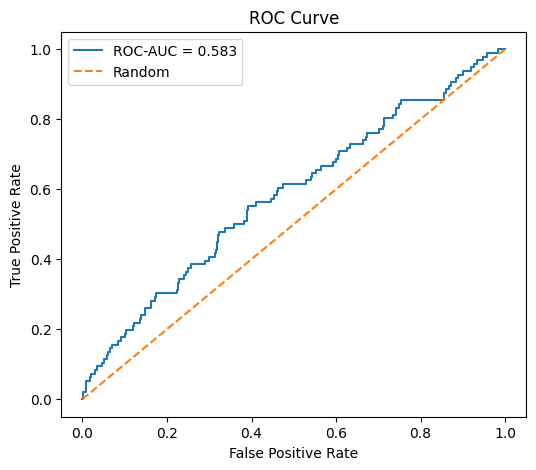

In [32]:
# CALCULATE ROC AND PRECISION-RECALL CURVES

fpr, tpr, _ = roc_curve(
    y_test,
    probability
)

precision, recall, _ = precision_recall_curve(
    y_test,
    probability
)

# Create the ROC curve.
plt.figure(figsize=(6, 5))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc:.3f}"
)

# Random classifier reference line.
plt.plot(
    [0, 1],
    [0, 1],
    "--",
    label="Random"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

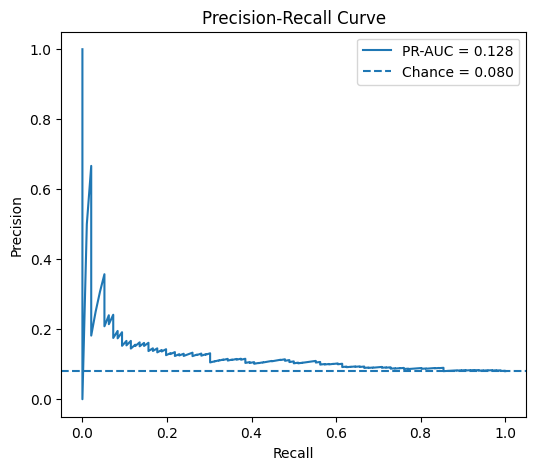

In [33]:
# ---------------------------------------------------------
# PRECISION-RECALL CURVE
# ---------------------------------------------------------

plt.figure(figsize=(6, 5))

plt.plot(
    recall,
    precision,
    label=f"PR-AUC = {pr_auc:.3f}"
)

# The prevalence is the PR-AUC baseline for a random ranking.
plt.axhline(
    y=y_test.mean(),
    linestyle="--",
    label=f"Chance = {y_test.mean():.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()

plt.show()

## 11. Calibration

### What does calibration mean?

A model may rank customers correctly but still produce probabilities that are not trustworthy.

For example, if a group of customers receives a predicted fraud probability of 20%, we would like approximately 20% of that group to actually be fraudulent.

A well-calibrated model therefore produces probabilities that correspond reasonably well to observed outcomes.

We compare:

- the original Logistic Regression probabilities;
- probabilities after isotonic calibration.

We also calculate the **Brier score**. Lower Brier scores indicate better probabilistic accuracy.

In [34]:
# CALIBRATE THE LOGISTIC REGRESSION MODEL

# Original probabilities.
p_uncalibrated = logistic_pipeline.predict_proba(X_test)[:, 1]

# Calibrate the already-defined pipeline.
# Calibration is fitted using the training data only.
calibrated_model = CalibratedClassifierCV(logistic_pipeline,method="isotonic",cv=5)

calibrated_model.fit(
    X_train,
    y_train
)

# Get calibrated probabilities.
p_calibrated = calibrated_model.predict_proba(
    X_test
)[:, 1]

In [35]:
# COMPARE UNCALIBRATED AND CALIBRATED PROBABILITIES

for name, probability_values in [
    ("Uncalibrated", p_uncalibrated),
    ("Isotonic", p_calibrated)
]:

    roc = roc_auc_score(
        y_test,
        probability_values
    )

    pr = average_precision_score(
        y_test,
        probability_values
    )

    brier = brier_score_loss(
        y_test,
        probability_values
    )

    print(
        f"{name}: "
        f"ROC-AUC = {roc:.3f}, "
        f"PR-AUC = {pr:.3f}, "
        f"Brier = {brier:.4f}"
    )

Uncalibrated: ROC-AUC = 0.583, PR-AUC = 0.128, Brier = 0.0734
Isotonic: ROC-AUC = 0.583, PR-AUC = 0.126, Brier = 0.0731


## 12. Imbalance shoot-out

We now compare three approaches to the class imbalance problem.

### Approach 1 — Threshold moving

Keep the original Logistic Regression model but change the probability threshold.

### Approach 2 — Class weighting

Tell Logistic Regression to give more importance to the minority class.

### Approach 3 — SMOTE-NC

Create synthetic minority observations during model training.

**Important:** SMOTE-NC must happen inside the modelling pipeline. We must never oversample the complete dataset before cross-validation because that would allow information from validation observations to influence the training process.

In [36]:
# IMPORT SMOTE-NC

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTENC

### 12.1 Plain Logistic Regression

This is our reference model.

We do not change the training data or the model weights.

Later we can change its decision threshold.

In [37]:
# PLAIN LOGISTIC REGRESSION

plain_model = Pipeline([
    (
        "preprocessing",
        preprocessor
    ),
    (
        "model",
        LogisticRegression(
            C=1.0,
            max_iter=2000
        )
    )
])

### 12.2 Logistic Regression with class weighting

`class_weight="balanced"` increases the importance of the minority class during training.

The data itself is not changed. Instead, the model gives more weight to fraud observations when calculating the loss.

In [38]:
# ---------------------------------------------------------
# LOGISTIC REGRESSION WITH CLASS WEIGHTING
# ---------------------------------------------------------

weighted_model = Pipeline([
    (
        "preprocessing",
        preprocessor
    ),
    (
        "model",
        LogisticRegression(
            class_weight="balanced",
            C=1.0,
            max_iter=2000
        )
    )
])

### 12.3 SMOTE-NC

SMOTE creates synthetic minority observations.

Because our data contains both numerical and categorical variables, we use **SMOTE-NC**.

For SMOTE-NC:

1. Numerical variables are imputed.
2. Categorical variables are ordinal encoded.
3. SMOTE-NC generates synthetic minority observations.
4. The resulting data is transformed for the final model.
5. Logistic Regression is trained.

All of these steps are inside an imbalanced-learn pipeline.

In [39]:

# PREPROCESSING FOR SMOTE-NC

# Numerical features only need missing-value treatment
# before SMOTE-NC.
smote_numeric = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    )
])

# Categorical features need imputation and ordinal encoding.
# Ordinal encoding temporarily represents categories as numbers
# so that SMOTE-NC can identify which variables are categorical.

smote_categorical = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1
        )
    )
])

# Combine the numerical and categorical preprocessing.
smote_preprocessor = ColumnTransformer([
    (
        "numeric",
        smote_numeric,
        NUM
    ),
    (
        "categorical",
        smote_categorical,
        CAT
    )
])

# After SMOTE-NC, scale numerical variables and one-hot encode
# categorical variables for Logistic Regression.
numeric_count = len(NUM)
categorical_indices = list(
    range(
        numeric_count,
        numeric_count + len(CAT)
    )
)

post_smote = ColumnTransformer([
    (
        "numeric",
        StandardScaler(),
        list(range(numeric_count))
    ),
    (
        "categorical",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ),
        categorical_indices
    )
])

# Tell SMOTE-NC which columns are categorical.
smote_model = ImbPipeline([
    (
        "pre_smote",
        smote_preprocessor
    ),
    (
        "smote",
        SMOTENC(
            categorical_features=categorical_indices,
            random_state=42
        )
    ),
    (
        "post_smote",
        post_smote
    ),
    (
        "model",
        LogisticRegression(
            C=1.0,
            max_iter=2000
        )
    )
])

## 13. Compare the imbalance methods using cross-validation

We use exactly the same stratified 5-fold cross-validation for all three approaches.

The main metric here is PR-AUC because we want to know whether the imbalance method improves ranking of the rare fraud class.

In [40]:
# COMPARE IMBALANCE METHODS

remedies = {
    "Threshold / Plain": plain_model,
    "Class Weight": weighted_model,
    "SMOTE-NC": smote_model
}

for name, model in remedies.items():

    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring="average_precision"
    )

    mean_score = scores["test_score"].mean()
    std_score = scores["test_score"].std()

    print(
        f"{name}: "
        f"PR-AUC = {mean_score:.3f} "
        f"+/- {std_score:.3f}"
    )

Threshold / Plain: PR-AUC = 0.132 +/- 0.034
Class Weight: PR-AUC = 0.132 +/- 0.031
SMOTE-NC: PR-AUC = 0.126 +/- 0.019


## 14. Threshold and business cost

The machine-learning model gives a probability, but the business needs a decision:

> Should this customer be flagged for investigation?

The usual threshold is 0.50, but that is not automatically appropriate.

Our business costs are:

- FN = KES 10,000
- FP = KES 800

Because a missed fraud case is much more expensive, the mathematically cost-optimal threshold is:

`t* = 800 / (800 + 10,000) ≈ 0.074`

This is why the decision threshold can be much lower than 0.50.

In [41]:
# ---------------------------------------------------------
# COST-OPTIMAL THRESHOLD
# ---------------------------------------------------------

print(
    f"Cost-optimal threshold = {T_STAR:.4f}"
)

print(
    "This means we flag a customer when the calibrated "
    "fraud probability is at least this value."
)

Cost-optimal threshold = 0.0741
This means we flag a customer when the calibrated fraud probability is at least this value.


## 15. Find the minimum expected cost for each imbalance method

For the plain model, class weighting and SMOTE-NC can change the probability distribution.

Therefore, rather than assuming that `0.50` or `T_STAR` is appropriate for every model, we sweep across possible thresholds and find the threshold that produces the lowest observed cost on the hold-out set.

The cost is:

`Total Cost = FN × C_FN + FP × C_FP`

We then convert the result to an expected cost per 1,000 applications so that the result is easy to communicate.

In [42]:
# ---------------------------------------------------------
# FUNCTION TO FIND THE MINIMUM BUSINESS COST
# ---------------------------------------------------------

def minimum_cost(y_true, probability, per=1000):

    # Test all unique probability values as possible thresholds.
    thresholds = np.unique(probability)

    best_cost = np.inf
    best_threshold = 0.5

    for threshold in thresholds:

        # Convert probabilities into class decisions.
        prediction = (
            probability >= threshold
        ).astype(int)

        # Calculate the confusion matrix.
        tn, fp, fn, tp = confusion_matrix(
            y_true,
            prediction,
            labels=[0, 1]
        ).ravel()

        # Calculate total business cost.
        cost = (
            C_FN * fn
            +
            C_FP * fp
        )

        # Keep the cheapest threshold.
        if cost < best_cost:
            best_cost = cost
            best_threshold = threshold

    # Convert total cost into cost per 1,000 cases.
    cost_per_1000 = (
        best_cost / len(y_true)
    ) * per

    return cost_per_1000, best_threshold

In [43]:
# ---------------------------------------------------------
# EVALUATE THE THREE IMBALANCE APPROACHES ON THE TEST SET
# ---------------------------------------------------------

print(
    f"{'Method':20s}"
    f"{'PR-AUC':>10s}"
    f"{'Cost/1000':>15s}"
    f"{'Best Threshold':>17s}"
)

for name, model in remedies.items():

    # Train the model using training data only.
    model.fit(
        X_train,
        y_train
    )

    # Get fraud probabilities.
    probability_values = model.predict_proba(
        X_test
    )[:, 1]

    # Calculate PR-AUC.
    pr_auc_value = average_precision_score(
        y_test,
        probability_values
    )

    # Find the cheapest threshold.
    cost, threshold = minimum_cost(
        y_test,
        probability_values
    )

    print(
        f"{name:20s}"
        f"{pr_auc_value:10.3f}"
        f"{cost:15,.0f}"
        f"{threshold:17.3f}"
    )

Method                  PR-AUC      Cost/1000   Best Threshold


Threshold / Plain        0.128        646,745            0.079
Class Weight             0.134        633,389            0.560
SMOTE-NC                 0.121        652,421            0.490


## 16. Why threshold moving is important

The comparison above lets us ask two different questions:

### Question 1 — Which model ranks fraud best?

Use **PR-AUC**.

### Question 2 — Which operating point costs the business the least?

Use the **expected business cost**.

These are not necessarily the same thing.

A model can have similar PR-AUC to another model but produce a different cost at the operating threshold.

For this lab, threshold moving is attractive because it is simple and reversible: we can change the decision rule without retraining the underlying Logistic Regression model.

## 17. Final decision model

We now return to the calibrated Logistic Regression model.

Why?

Because our final threshold is based on probability and business cost. Calibration makes the probabilities more interpretable.

We use:

`t* ≈ 0.074`

The final rule is:

> **Flag the customer for review if calibrated fraud probability ≥ 0.074.**

In [44]:
# ---------------------------------------------------------
# FINAL DECISION USING THE CALIBRATED MODEL
# ---------------------------------------------------------

# Apply the business threshold to calibrated probabilities.
final_prediction = (p_calibrated >= T_STAR).astype(int)

# Calculate the confusion matrix.
tn, fp, fn, tp = confusion_matrix(
    y_test,
    final_prediction,
    labels=[0, 1]
).ravel()

print("Confusion matrix:")
print(f"True Negatives : {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives : {tp}")

Confusion matrix:
True Negatives : 534
False Positives: 568
False Negatives: 37
True Positives : 59


## 18. Calculate recall, precision and business cost

The confusion matrix allows us to calculate the operational measures.

### Recall

Of all actual fraud cases, what percentage did we catch?

`Recall = TP / (TP + FN)`

### Precision

Of all cases we flagged, what percentage were actually fraud?

`Precision = TP / (TP + FP)`

### Expected cost

`Cost = FN × 10,000 + FP × 800`

We also report cost per 1,000 applications because it provides an easier business interpretation.

In [45]:
# FINAL PERFORMANCE AND BUSINESS COST

recall = tp / (tp + fn)

if (tp + fp) > 0:
    precision = tp / (tp + fp)
else:
    precision = 0

total_cost = (C_FN * fn+C_FP * fp)

cost_per_1000 = (
    total_cost / len(y_test)
) * 1000

print(f"Recall              = {recall:.3f}")
print(f"Precision           = {precision:.3f}")
print(f"Total business cost = KES {total_cost:,.0f}")
print(f"Cost per 1,000      = KES {cost_per_1000:,.0f}")

Recall              = 0.615
Precision           = 0.094
Total business cost = KES 824,400
Cost per 1,000      = KES 688,147


## 19. Compare with the traditional 0.50 threshold

A common mistake is to automatically use 0.50 as the classification threshold.

We compare the business cost of:

- our cost-based threshold of approximately 0.074;
- the traditional threshold of 0.50.

This demonstrates why the correct threshold depends on the business problem rather than being a universal machine-learning rule.

In [46]:
# COMPARE COST-BASED THRESHOLD WITH 0.50

# Predictions using the normal 0.50 threshold.
prediction_50 = (
    p_calibrated >= 0.50
).astype(int)

tn50, fp50, fn50, tp50 = confusion_matrix(
    y_test,
    prediction_50,
    labels=[0, 1]
).ravel()

cost_50          = ( C_FN * fn50+C_FP * fp50)
cost_50_per_1000 = (cost_50 / len(y_test)) * 1000

print(
    f"Cost at threshold {T_STAR:.3f}: "
    f"KES {cost_per_1000:,.0f} per 1,000"
)

print(
    f"Cost at threshold 0.500: "
    f"KES {cost_50_per_1000:,.0f} per 1,000"
)

Cost at threshold 0.074: KES 688,147 per 1,000
Cost at threshold 0.500: KES 801,336 per 1,000


# 20. Final decision memo

## Recommended operating rule

Use the **calibrated Logistic Regression model** and flag customers when:

**Predicted fraud probability ≥ 0.074**

### Why?

A false negative costs KES 10,000 while a false positive costs KES 800.

Therefore, missing fraud is approximately 12.5 times more expensive than creating a false alarm.

A lower threshold is therefore appropriate because the business would rather investigate additional customers than miss too many fraudulent cases.

### What should be monitored?

Before deployment, monitor:

- Recall by region.
- Precision by region.
- Recall by customer segment.
- Precision by customer segment.
- Fraud prevalence over time.
- Calibration of predicted probabilities.
- Actual financial cost.

If the fraud rate or business cost assumptions change, the threshold should be reviewed.

### Important lesson

There is no single "best" classification threshold.

The threshold should reflect:

**Model probabilities + class imbalance + business costs + operational capacity.**

# Summary of the lab

We have learned that:

1. **Accuracy can be misleading** when the positive class is rare.
2. **PR-AUC is particularly useful** for imbalanced classification.
3. **Pipelines** allow preprocessing and modelling to be handled together.
4. **Stratified cross-validation** preserves the class distribution across folds.
5. **Calibration** makes predicted probabilities more useful for decision-making.
6. **Class weighting and SMOTE-NC** are alternative ways of addressing class imbalance.
7. **Threshold moving** changes the final decision without necessarily changing model ranking.
8. **Business costs should determine the operating threshold** when the costs of errors are asymmetric.
9. A good machine-learning model is not only about predictive performance; it must also support a sensible business decision.